# mCH trinucleotide context (Fig 3B)

Non-CG methylation by trinucleotide context (CAC, CAG, …) across major cell types, and
identification of the cell types with the highest mCA.

_The lambda-normalized context heatmaps (a tentative Fig S16) are omitted — the published
values/styling could not be matched._

## 📥 Required input files
- `{ENTEX_ROOT}/analysis/mC_context/L2any-donor/*.context.tsv` · per-cluster trinucleotide-context counts
- `{ENTEX_ROOT}/clustering/merged/group_meta.tsv` · cluster → major-type map
- `{ENTEX_ROOT}/L1color.tsv` · major-type colors (provided)
- `{ENTEX_ROOT}/merged_allc/cluster_donor.mcds` · single-cell mC matrix (for the mCA-region step)

In [1]:
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')
import repro_guard

[repro_guard] active — READ-ONLY (all writes skipped; inline figures still render)


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from glob import glob
mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'
import warnings
warnings.filterwarnings('ignore')

indir = f'{ENTEX_ROOT}/'

## Build the trinucleotide-context methylation matrix
Read per-cluster context counts and assemble a cluster × context `mc`/`cov` table
(non-`N` contexts).

In [3]:
group_meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', sep='\t', header=0, index_col=0)
group_meta['L1_annot'] = group_meta['L1_annot'].str.replace(' ', '-').str.replace('/', '_')
L1annot = group_meta[['L1', 'L1_annot']].set_index('L1')['L1_annot'].to_dict()

In [4]:
file_list = np.sort(glob(f'{indir}analysis/mC_context/L2any-donor/*.context.tsv'))
mc, cov, cluster = [], [], []
for file in file_list:
    tmp = pd.read_csv(file, index_col=0, header=None, names=['context', 'mc', 'cov'], sep='\t')
    mc.append(tmp['mc']); cov.append(tmp['cov'])
    cluster.append(file.split('/')[-1].split('.')[0])
mc = pd.concat(mc, axis=1); mc.columns = cluster
cov = pd.concat(cov, axis=1); cov.columns = cluster
keep = np.array(['N' not in xx for xx in mc.index])   # drop ambiguous-base contexts
mc = mc.loc[keep].T
cov = cov.loc[keep].T

## Fig 3B — mCH by trinucleotide context across major types
Aggregate to major-type level (CH contexts only) and plot mC/C per context, one dot per
non-neuronal major type.

In [5]:
selch = np.array([xx[:2] != 'CG' for xx in mc.columns])
groupL1 = pd.Series(mc.index.str.split('-').str[0], index=mc.index)
mc_L1 = mc.groupby(groupL1).sum().loc[:, selch]
cov_L1 = cov.groupby(groupL1).sum().loc[:, selch]
colors = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)['color'].to_dict()

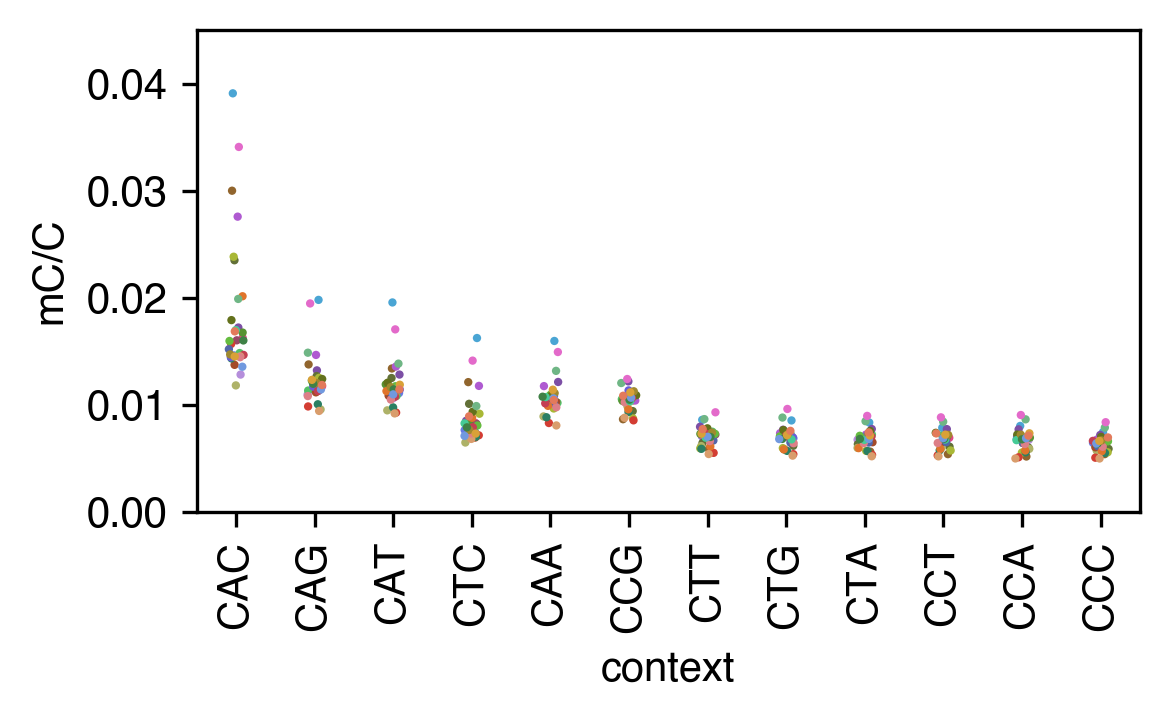

In [6]:
tmp = (mc_L1 + 1) / (cov_L1 + 1)
tmp.index.name = 'L1'
tmp = tmp.stack().reset_index()
neurons = tmp['L1'].isin(['c10', 'c16', 'c31'])          # excluded (plotted separately)
leg_order = tmp.groupby('context')[0].mean().sort_values().index[::-1]

fig, ax = plt.subplots(figsize=(4, 2.5), dpi=300)
sns.stripplot(data=tmp.loc[~neurons], x='context', y=0, hue='L1', palette=colors,
              order=leg_order, ax=ax, edgecolor='none', s=2)
ax.set_ylim([0, 0.045]); ax.set_yticks(np.arange(0, 0.05, 0.01))
ax.set_xticks(np.arange(selch.sum())); ax.set_xticklabels(leg_order, rotation=90)
ax.set_ylabel('mC/C'); ax.get_legend().remove()
fig.tight_layout()
fig.savefig('mCH_distribution/L1_context_scatter.pdf', transparent=True)   # Fig 3B

## High-mCA cell types → per-bin CA methylation ratio
A few cell types carry unusually high **mCA**. We take the 24 clusters with the highest mCA
(top-2 per major type, mCA/CA > 0.025, above lambda background — frozen in `selc`) and, from
the single-cell `cluster_donor.mcds`, compute each cluster's genome-wide **per-1 kb-bin CA
methylation ratio** (sex/organelle chromosomes dropped).

**Output `mC_context/L2any_mCA_025_top2_rawratio.hdf`** (clusters × 1 kb bins) is the input to
the downstream analysis of where high-mCA is deposited along the genome (high-CA vs low-CA
methylation-domain comparison and its motif enrichment).

In [7]:
selc = pd.Index(['c12-c10', 'c13-c5', 'c13-c9', 'c14-c1', 'c14-c2', 'c14-c3', 'c14-c6',
                 'c14-c7', 'c21-c8', 'c25-c10', 'c26-c10', 'c31-c0', 'c31-c1', 'c31-c2',
                 'c31-c3', 'c31-c4', 'c31-c5', 'c31-c6', 'c31-c7', 'c32-c2', 'c5-c1',
                 'c5-c2', 'c5-c5', 'c5-c9'])

In [8]:
from ALLCools.mcds import MCDS
mcds = MCDS.open(f'{indir}merged_allc/cluster_donor.mcds', var_dim='chrom1k')
# L2_any = majortype-subtype = first two parts of the cluster-donor cell id
mcds = mcds.assign_coords(L2_any=('cell', ['-'.join(x.split('-')[:2]) for x in mcds.get_index('cell')]))
mcds = mcds.groupby('L2_any').sum()
mcds = MCDS(mcds, obs_dim='L2_any', var_dim='chrom1k').sel({'mc_type': 'CAN'})

In [9]:
cov_mean = mcds['chrom1k_da'].sel(count_type='cov').mean(dim='L2_any').squeeze().to_pandas()
good_bins = cov_mean.index[cov_mean > 100]
sub = mcds.sel({'L2_any': selc, 'chrom1k': good_bins})
mc_bin  = sub.sel({'count_type': 'mc'})['chrom1k_da'].to_pandas()
cov_bin = sub.sel({'count_type': 'cov'})['chrom1k_da'].to_pandas()
# drop sex / organelle chromosomes by bin coordinate
chrom = sub['chrom1k_chrom'].to_pandas()
autobins = chrom.index[~chrom.isin(['chrX', 'chrY', 'chrM', 'chrL'])]
data = (mc_bin[autobins] / cov_bin[autobins])
data.to_hdf('mC_context/L2any_mCA_025_top2_rawratio.hdf', key='data')
data.shape

(24, 2635245)